# Model comparison: CitrusNet vs. transfer learning

Pulls together the from-scratch CitrusNet and the three fine-tuned transfer-learning models (ResNet50, EfficientNet-B0, DenseNet121) into one place: hyperparameters, training curves, and held-out test-set metrics.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load results
Class order matches the mapping used throughout the project.

In [2]:
CLASS_TO_IDX = {"aphids": 0, "gummosis": 1, "healthy": 2, "leaf_minnor": 3}
CLASSES = list(CLASS_TO_IDX.keys())

MODEL_ORDER = ["citrusnet", "resnet50", "efficientnet_b0", "densenet121"]

RESULT_FILES = {
    "citrusnet": "final_test_results_citrusnet.json",
    "resnet50": "final_test_results_resnet50.json",
    "efficientnet_b0": "final_test_results_efficientnet_b0.json",
    "densenet121": "final_test_results_densenet121.json",
}

results = {}
for arch, fname in RESULT_FILES.items():
    with open(fname) as f:
        results[arch] = json.load(f)

list(results.keys())

['citrusnet', 'resnet50', 'efficientnet_b0', 'densenet121']

Same model colors get reused in every plot below, so a color always means the same model.

In [3]:
MODEL_COLORS = {
    "citrusnet": "#1f77b4",
    "resnet50": "#ff7f0e",
    "efficientnet_b0": "#2ca02c",
    "densenet121": "#d62728",
}

## Master metrics table
One row per model. `macro_specificity` isn't stored directly in the result files, so it's computed here as the mean of the four per-class specificity values.

In [4]:
metrics_rows = []
for arch in MODEL_ORDER:
    r = results[arch]
    specificities = [r["per_class"][c]["specificity"] for c in CLASSES]
    metrics_rows.append({
        "architecture": arch,
        "test_accuracy": r["test_accuracy"],
        "macro_precision": r["macro_precision"],
        "macro_recall_sensitivity": r["macro_recall"],
        "macro_specificity": float(np.mean(specificities)),
        "macro_f1": r["macro_f1"],
        "mean_roc_auc": r["mean_roc_auc"],
        "param_count": r["param_count"],
        "model_size_mb": r["model_size_mb"],
        "mean_inference_latency_ms": r["mean_inference_latency_ms"],
        "throughput_images_per_sec": r["throughput_images_per_sec"],
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
print(metrics_df.to_string(index=False))
metrics_df.to_csv("model_comparison_metrics.csv", index=False)

   architecture  test_accuracy  macro_precision  macro_recall_sensitivity  macro_specificity  macro_f1  mean_roc_auc  param_count  model_size_mb  mean_inference_latency_ms  throughput_images_per_sec
       resnet50       0.995833         0.995192                  0.996094           0.998677  0.995604      1.000000     23770820      90.678482                   8.082305                 123.727080
    densenet121       0.987500         0.988401                  0.988401           0.995731  0.988372      0.999558      7085572      27.029312                  21.273749                  47.006289
      citrusnet       0.966667         0.965749                  0.969171           0.989117  0.966375      0.997139       416036       1.587051                   2.701898                 370.110197
efficientnet_b0       0.929167         0.943336                  0.933834           0.976349  0.932485      0.989402      4172032      15.915039                  18.068612                  55.344594


## Per-class detail table
One row per (model, class) pair, grouped by class so each class's performance is easy to compare across all four models.

In [5]:
detail_rows = []
for arch in MODEL_ORDER:
    r = results[arch]
    for c in CLASSES:
        pc = r["per_class"][c]
        detail_rows.append({
            "architecture": arch,
            "class": c,
            "precision": pc["precision"],
            "recall_sensitivity": pc["recall"],
            "specificity": pc["specificity"],
            "f1": pc["f1"],
            "roc_auc": pc["roc_auc"],
        })

detail_df = pd.DataFrame(detail_rows)
detail_df["architecture"] = pd.Categorical(detail_df["architecture"], categories=MODEL_ORDER, ordered=True)
detail_df["class"] = pd.Categorical(detail_df["class"], categories=CLASSES, ordered=True)
detail_df = detail_df.sort_values(["class", "architecture"]).reset_index(drop=True)

print(detail_df.to_string(index=False))
detail_df.to_csv("model_comparison_per_class.csv", index=False)

   architecture       class  precision  recall_sensitivity  specificity       f1  roc_auc
      citrusnet      aphids   1.000000            1.000000     1.000000 1.000000 1.000000
       resnet50      aphids   1.000000            1.000000     1.000000 1.000000 1.000000
efficientnet_b0      aphids   0.789474            1.000000     0.911111 0.882353 0.980741
    densenet121      aphids   1.000000            1.000000     1.000000 1.000000 1.000000
      citrusnet    gummosis   0.983051            0.892308     0.994286 0.935484 0.999297
       resnet50    gummosis   1.000000            1.000000     1.000000 1.000000 1.000000
efficientnet_b0    gummosis   0.983871            0.938462     0.994286 0.960630 0.996220
    densenet121    gummosis   0.984375            0.969231     0.994286 0.976744 0.999385
      citrusnet     healthy   0.910714            1.000000     0.973545 0.953271 1.000000
       resnet50     healthy   0.980769            1.000000     0.994709 0.990291 1.000000
efficientn

## Hyperparameter comparison
CitrusNet's baseline hyperparameters were never written to a CSV, so they're hardcoded here. It also wasn't fine-tuned in two phases like the transfer-learning models, so the phase1/phase2 columns don't apply to it and are left as N/A.

In [6]:
CITRUSNET_HPARAMS = {
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 32,
    "dropout": 0.5,
    "max_epochs": 100,
    "early_stop_patience": 10,
    "scheduler": "ReduceLROnPlateau",
    "pretrained_on": "none (trained from scratch)",
    "total_params": 416036,
    "classifier_head": "Linear(256,128)-ReLU-Dropout(0.5)-Linear(128,4)",
}

tl_hparams_df = pd.read_csv("hyperparameters_transfer_learning.csv")

NA_PHASE = "N/A (single-phase training)"
citrusnet_row = {
    "architecture": "citrusnet",
    "pretrained_on": CITRUSNET_HPARAMS["pretrained_on"],
    "phase1_lr": NA_PHASE,
    "phase1_max_epochs": NA_PHASE,
    "phase1_early_stop_patience": NA_PHASE,
    "phase2_lr": NA_PHASE,
    "phase2_max_epochs": NA_PHASE,
    "phase2_early_stop_patience": NA_PHASE,
    "batch_size": CITRUSNET_HPARAMS["batch_size"],
    "weight_decay": CITRUSNET_HPARAMS["weight_decay"],
    "dropout": CITRUSNET_HPARAMS["dropout"],
    "optimizer": CITRUSNET_HPARAMS["optimizer"],
    "scheduler": CITRUSNET_HPARAMS["scheduler"],
    "total_params": CITRUSNET_HPARAMS["total_params"],
    "classifier_head": CITRUSNET_HPARAMS["classifier_head"],
}

hparams_df = pd.concat([pd.DataFrame([citrusnet_row]), tl_hparams_df], ignore_index=True)
hparams_df = hparams_df[list(citrusnet_row.keys())]

print(hparams_df.to_string(index=False))
hparams_df.to_csv("model_comparison_hyperparameters.csv", index=False)

   architecture               pretrained_on                   phase1_lr           phase1_max_epochs  phase1_early_stop_patience                   phase2_lr           phase2_max_epochs  phase2_early_stop_patience  batch_size  weight_decay  dropout optimizer         scheduler  total_params                                 classifier_head
      citrusnet none (trained from scratch) N/A (single-phase training) N/A (single-phase training) N/A (single-phase training) N/A (single-phase training) N/A (single-phase training) N/A (single-phase training)          32        0.0001      0.5      Adam ReduceLROnPlateau        416036 Linear(256,128)-ReLU-Dropout(0.5)-Linear(128,4)
       resnet50                  ImageNet1K                       0.001                          15                           5                      0.0001                          50                          10          16        0.0001      0.5      Adam ReduceLROnPlateau      23770820  Linear(in,128)-ReLU-Dropout(0.5)-Lin

## Main results figure

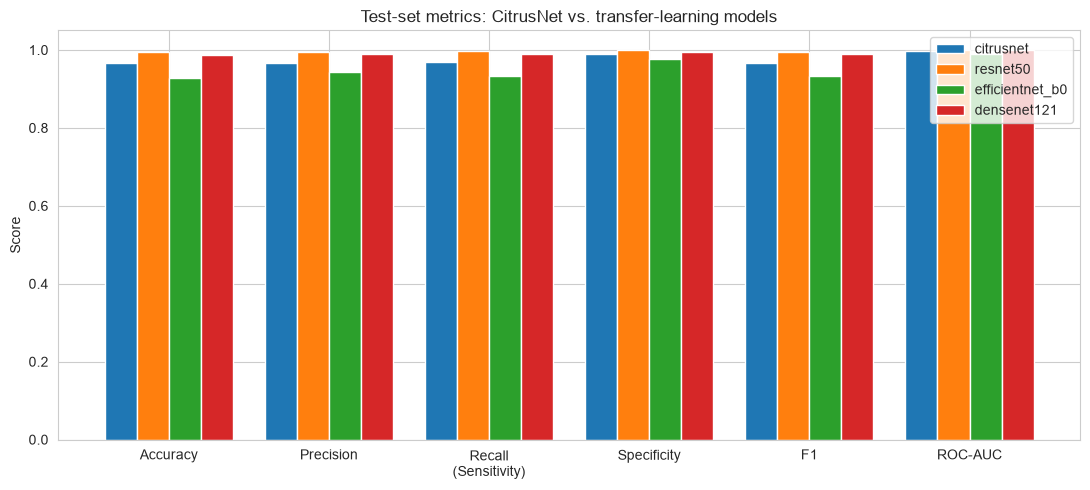

In [7]:
metric_cols = ["test_accuracy", "macro_precision", "macro_recall_sensitivity",
               "macro_specificity", "macro_f1", "mean_roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall\n(Sensitivity)", "Specificity", "F1", "ROC-AUC"]

plot_df = metrics_df.set_index("architecture").loc[MODEL_ORDER, metric_cols]

x = np.arange(len(metric_cols))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, arch in enumerate(MODEL_ORDER):
    ax.bar(x + (i - 1.5) * width, plot_df.loc[arch], width, label=arch, color=MODEL_COLORS[arch])

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Test-set metrics: CitrusNet vs. transfer-learning models")
ax.legend()
plt.tight_layout()
plt.show()

## Efficiency: size and speed

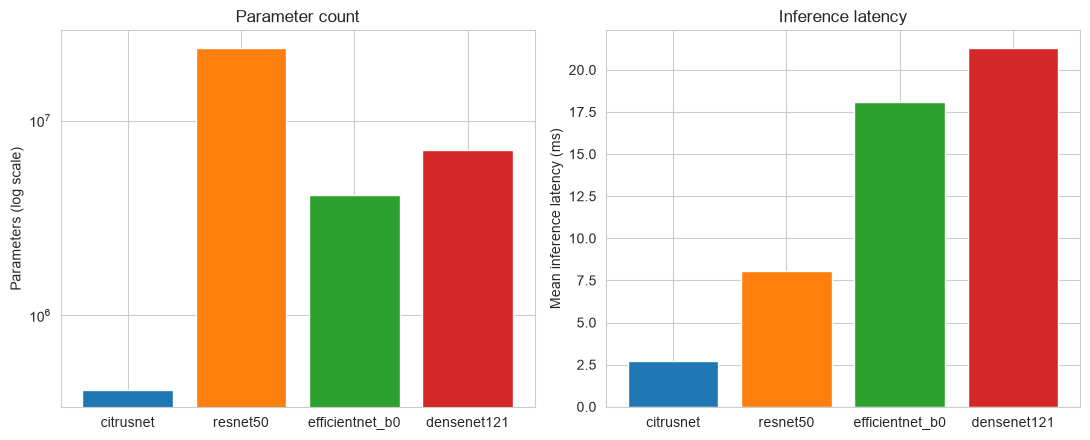

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

metrics_indexed = metrics_df.set_index("architecture")

for arch in MODEL_ORDER:
    axes[0].bar(arch, metrics_indexed.loc[arch, "param_count"], color=MODEL_COLORS[arch])
axes[0].set_yscale("log")
axes[0].set_ylabel("Parameters (log scale)")
axes[0].set_title("Parameter count")

for arch in MODEL_ORDER:
    axes[1].bar(arch, metrics_indexed.loc[arch, "mean_inference_latency_ms"], color=MODEL_COLORS[arch])
axes[1].set_ylabel("Mean inference latency (ms)")
axes[1].set_title("Inference latency")

plt.tight_layout()
plt.show()

## Accuracy vs. model size tradeoff

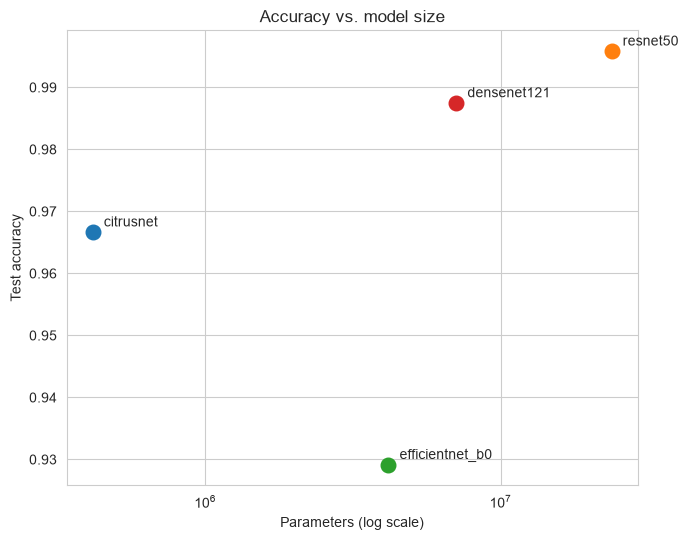

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for arch in MODEL_ORDER:
    row = metrics_indexed.loc[arch]
    ax.scatter(row["param_count"], row["test_accuracy"], color=MODEL_COLORS[arch], s=110, zorder=3)
    ax.annotate(arch, (row["param_count"], row["test_accuracy"]), textcoords="offset points", xytext=(8, 4))

ax.set_xscale("log")
ax.set_xlabel("Parameters (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Accuracy vs. model size")
plt.tight_layout()
plt.show()

ResNet50 has the best accuracy of the four here but is also the largest model by a wide margin. CitrusNet sits at the other end: smallest by more than an order of magnitude and still within a couple points of DenseNet121. EfficientNet-B0 doesn't have a good spot on this plot -- it's not close to the smallest model and it has the lowest accuracy of the four, so CitrusNet beats it on both axes at once.

Training histories aren't directly comparable epoch-for-epoch: CitrusNet's epochs are single-phase from-scratch training, while the transfer-learning models' epochs combine phase-1 (frozen backbone) and phase-2 (fine-tuned) epoch numbering, as built in notebook 13. The plots below are useful for comparing convergence behavior qualitatively, not for comparing training cost epoch-for-epoch.

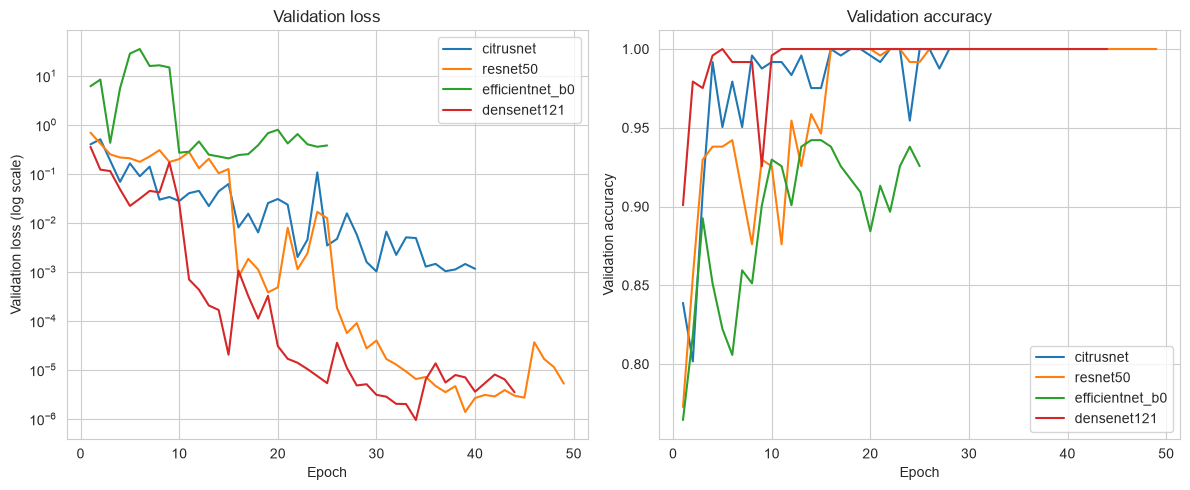

In [10]:
HISTORY_FILES = {
    "citrusnet": "history_baseline.csv",
    "resnet50": "history_tl_resnet50.csv",
    "efficientnet_b0": "history_tl_efficientnet_b0.csv",
    "densenet121": "history_tl_densenet121.csv",
}

histories = {arch: pd.read_csv(fname) for arch, fname in HISTORY_FILES.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for arch in MODEL_ORDER:
    h = histories[arch]
    axes[0].plot(h["epoch"], h["val_loss"], color=MODEL_COLORS[arch], label=arch)
    axes[1].plot(h["epoch"], h["val_acc"], color=MODEL_COLORS[arch], label=arch)

axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation loss (log scale)")
axes[0].set_title("Validation loss")
axes[0].legend()

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Validation accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final report card

In [11]:
ranked = metrics_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)
smallest = metrics_df.loc[metrics_df["param_count"].idxmin()]
fastest = metrics_df.loc[metrics_df["mean_inference_latency_ms"].idxmin()]

print("FINAL REPORT CARD")
print("=" * 40)

print("\nRanked by test accuracy:")
for i, row in ranked.iterrows():
    print(f"  {i + 1}. {row['architecture']:<16} {row['test_accuracy'] * 100:.2f}%")

print(f"\nSmallest model:  {smallest['architecture']} ({int(smallest['param_count']):,} params)")
print(f"Fastest model:   {fastest['architecture']} ({fastest['mean_inference_latency_ms']:.2f} ms/image)")

print("\nAccuracy vs. parameter count, pairwise:")
for i, a in enumerate(MODEL_ORDER):
    row_a = metrics_indexed.loc[a]
    for b in MODEL_ORDER[i + 1:]:
        row_b = metrics_indexed.loc[b]
        a_better_acc = row_a["test_accuracy"] > row_b["test_accuracy"]
        a_smaller = row_a["param_count"] < row_b["param_count"]
        if a_better_acc and a_smaller:
            print(f"  {a} dominates {b}: better accuracy and fewer parameters")
        elif (not a_better_acc) and (not a_smaller):
            print(f"  {b} dominates {a}: better accuracy and fewer parameters")
        else:
            better_acc = a if a_better_acc else b
            smaller = a if a_smaller else b
            print(f"  {a} vs {b}: genuine tradeoff -- {better_acc} more accurate, {smaller} smaller")

FINAL REPORT CARD

Ranked by test accuracy:
  1. resnet50         99.58%
  2. densenet121      98.75%
  3. citrusnet        96.67%
  4. efficientnet_b0  92.92%

Smallest model:  citrusnet (416,036 params)
Fastest model:   citrusnet (2.70 ms/image)

Accuracy vs. parameter count, pairwise:
  citrusnet vs resnet50: genuine tradeoff -- resnet50 more accurate, citrusnet smaller
  citrusnet dominates efficientnet_b0: better accuracy and fewer parameters
  citrusnet vs densenet121: genuine tradeoff -- densenet121 more accurate, citrusnet smaller
  resnet50 vs efficientnet_b0: genuine tradeoff -- resnet50 more accurate, efficientnet_b0 smaller
  resnet50 vs densenet121: genuine tradeoff -- resnet50 more accurate, densenet121 smaller
  efficientnet_b0 vs densenet121: genuine tradeoff -- densenet121 more accurate, efficientnet_b0 smaller
